### 课程一（15%）

##### 1.环境配置

编译器安装:Visual Studio Code/Pycharm

Python环境管理:Python虚拟环境搭建(conda/venv),推荐安装anaconda/miniconda进行环境管理

https://blog.csdn.net/ming12131342/article/details/140233867

验证安装，终端运行 `conda --version`

换源：[ubuntu、conda、pip 换北外源（北京外国语大学开源软件镜像站）_北外临时源-CSDN博客](https://blog.csdn.net/weixin_43667077/article/details/108282523)

创建虚拟环境

`conda create -n speech_env python=3.8 `

`conda activate speech_env`

##### 2.安装numpy,matplotlib,librosa,pandas

In [3]:
%pip install numpy matplotlib librosa pandas

Could not fetch URL https://pypi.org/simple/pip/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/pip/ (Caused by SSLError(SSLZeroReturnError(6, 'TLS/SSL connection has been closed (EOF) (_ssl.c:1149)'))) - skipping
Note: you may need to restart the kernel to use updated packages.


##### 3.导入librosa,pandas,numpy,matplotlib,IPython

In [4]:
import librosa  
import matplotlib.pyplot as plt  
import IPython.display as ipd
import pandas as pd
import numpy as np

##### 4.使用IPython展示音频

In [5]:
audio_file = 'LJ001-0011.wav'
ipd.Audio(audio_file)

##### 5.使用librosa加载音频,打印加载的音频shape,音频采样率

In [6]:
y, sr = librosa.load(audio_file)
print(type(y))
print(f'shape y: {y.shape}')
print(f'sr: {sr}')

<class 'numpy.ndarray'>
shape y: (99485,)
sr: 22050


##### 6.使用matplotlib包绘制音频

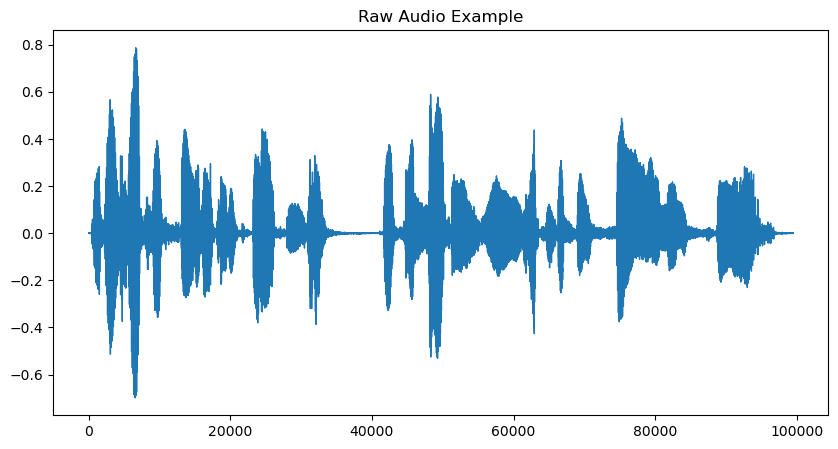

In [7]:
#序列化音频数据
pd.Series(y).plot(figsize=(10, 5),
                  lw=1,
                  title='Raw Audio Example')
plt.show()

##### 7.使用librosa计算音频的幅度谱图,打印幅度谱shape并使用matplotlib进行绘制

(1025, 195)


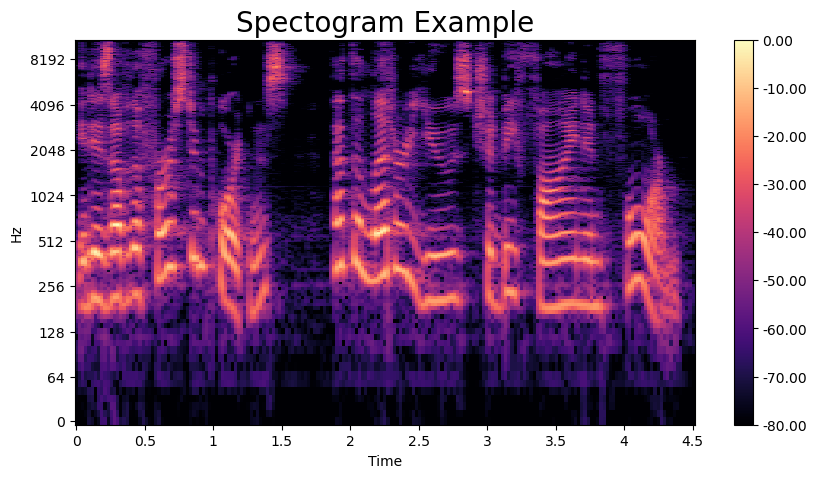

In [8]:
#把加载的音频通过短时傅里叶变换
D = librosa.stft(y)
#取复数矩阵的模,得到幅度
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
print(S_db.shape)

# Plot the transformed audio data
fig, ax = plt.subplots(figsize=(10, 5))
img = librosa.display.specshow(S_db,
                              x_axis='time',
                              y_axis='log',
                              ax=ax)
ax.set_title('Spectogram Example', fontsize=20)
fig.colorbar(img, ax=ax, format=f'%0.2f')
plt.show()

##### 8.使用librosa计算并绘制mel谱

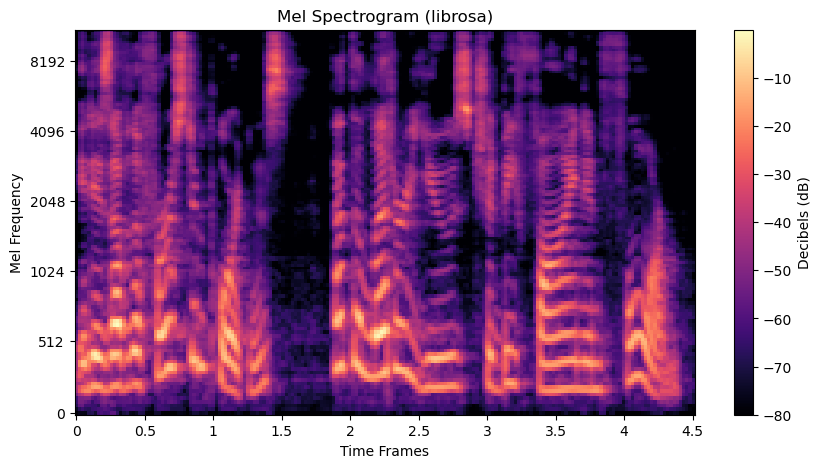

In [9]:
n_fft = 2048       # FFT 大小
hop_length = 512   # 帧移
n_mels = 128       # Mel 频带数
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(10, 5))
librosa.display.specshow(mel_spec_db, sr=sr, hop_length=hop_length, x_axis="time", y_axis="mel")
plt.colorbar(label="Decibels (dB)")
plt.xlabel("Time Frames")
plt.ylabel("Mel Frequency")
plt.title("Mel Spectrogram (librosa)")
plt.show()

##### 9.安装torch,torchaudio
https://pytorch.org/

GPU环境搭建：

https://blog.csdn.net/2501_91798322/article/details/154492010

In [10]:
%pip install torch torchaudio

Could not fetch URL https://pypi.org/simple/pip/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/pip/ (Caused by SSLError(SSLZeroReturnError(6, 'TLS/SSL connection has been closed (EOF) (_ssl.c:1149)'))) - skipping
Note: you may need to restart the kernel to use updated packages.


In [11]:
import torch, torchaudio
print(torch.__version__)
print(torch.cuda.is_available()) 

1.13.1
False


##### 10.使用torchaudio加载音频,计算mel谱并绘制

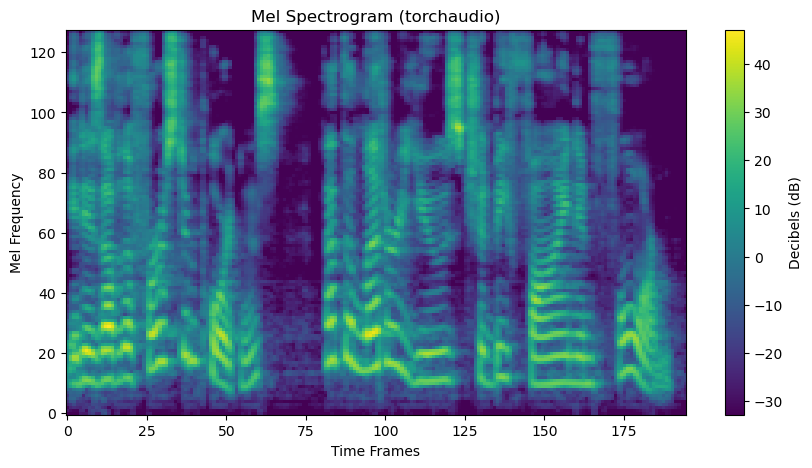

In [12]:
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
waveform, sample_rate = torchaudio.load("LJ001-0011.wav") 

n_fft = 2048  
n_mels = 128   
hop_length = 512  

# TODO：调用函数计算 Mel 频谱图（已完成）
mel_transform = T.MelSpectrogram(
    sample_rate=sample_rate,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels,
    power=2.0
 )
mel_spec = mel_transform(waveform)
mel_spec_db = T.AmplitudeToDB(stype="power", top_db=80)(mel_spec)

plt.figure(figsize=(10, 5))
plt.imshow(mel_spec_db[0].numpy(), aspect="auto", origin="lower")
plt.colorbar(label="Decibels (dB)")
plt.xlabel("Time Frames")
plt.ylabel("Mel Frequency")
plt.title("Mel Spectrogram (torchaudio)")
plt.show()

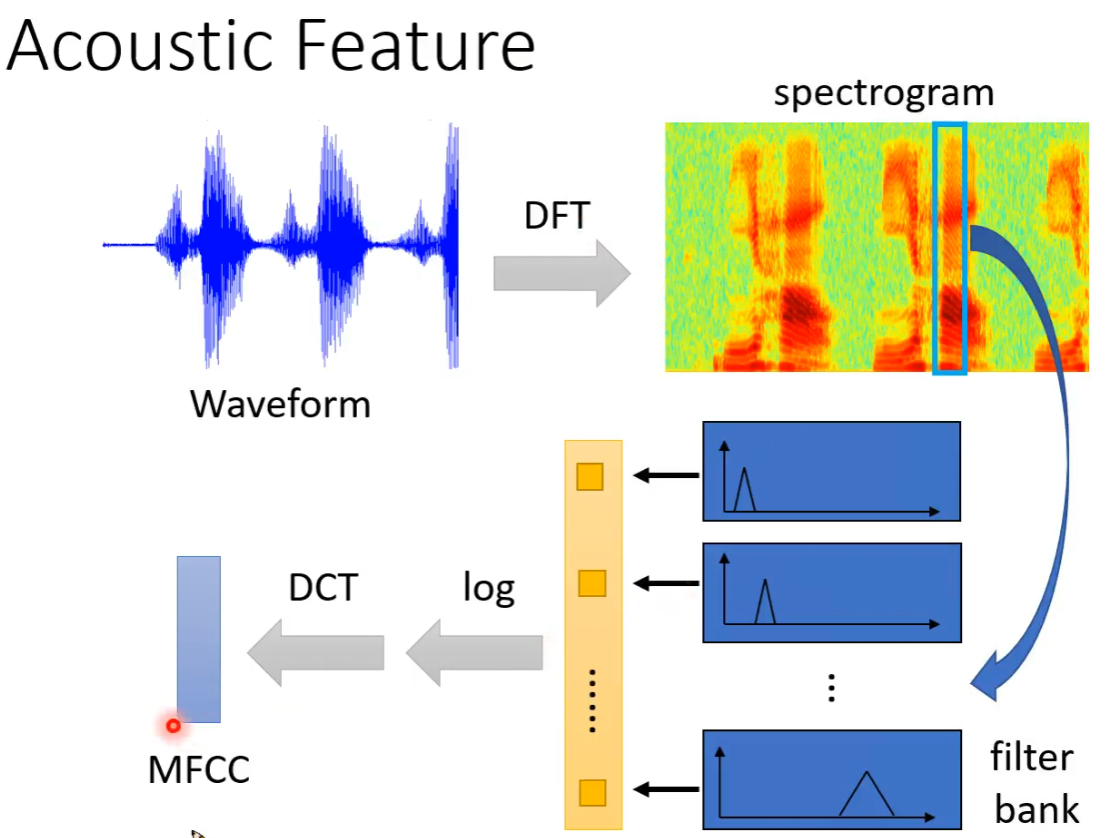
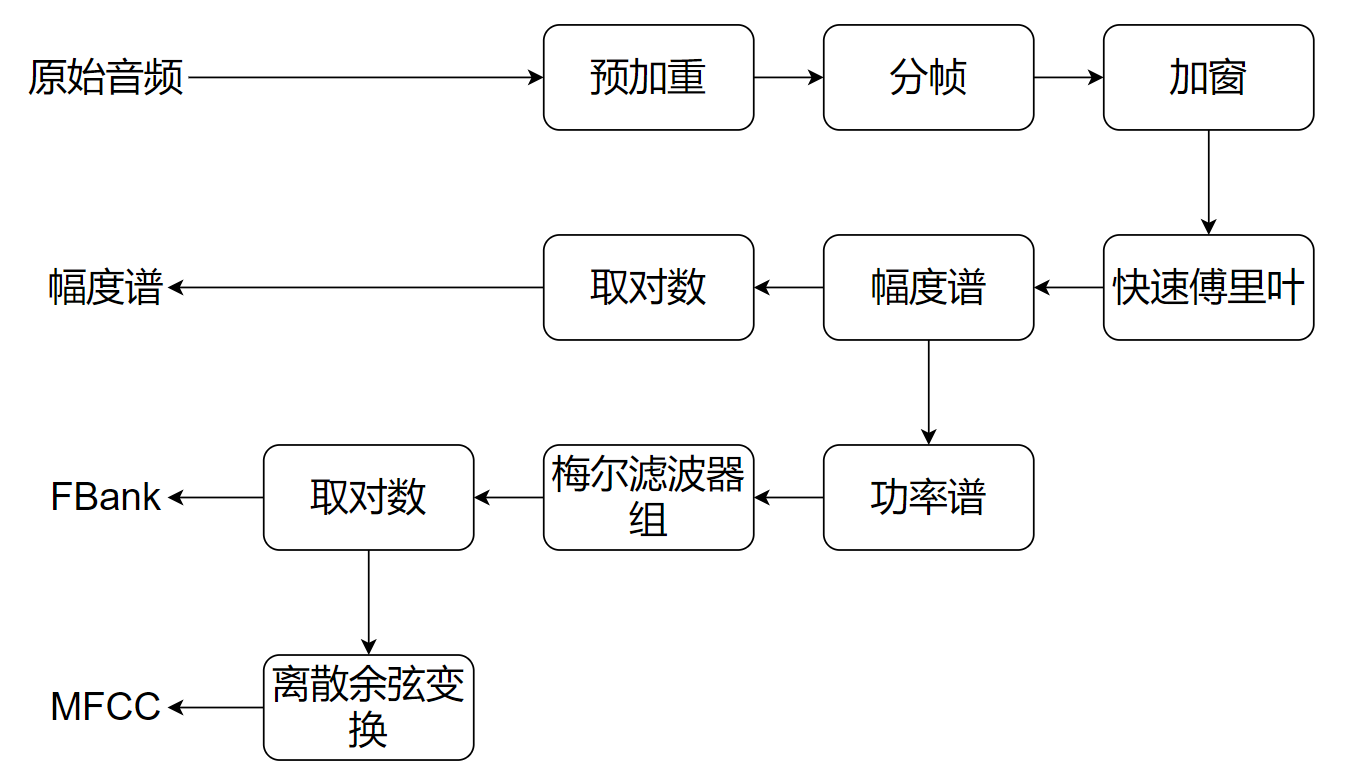 


### 课程二（30%）

自行构建幅度谱

##### 1.librosa加载音频

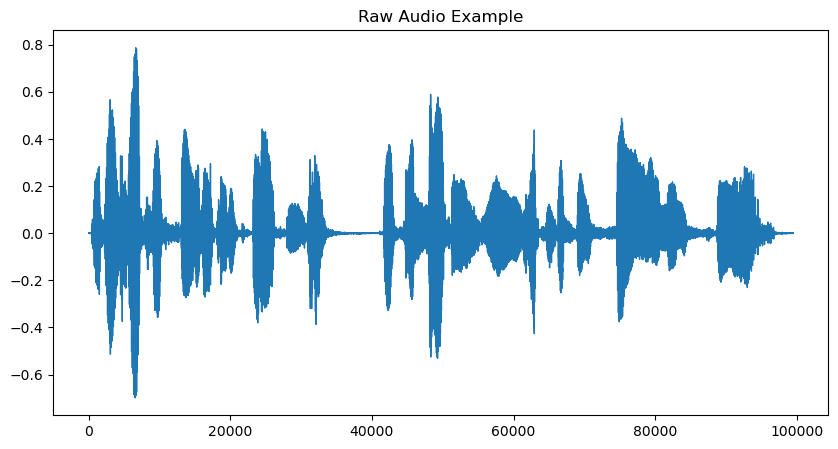

In [13]:
audio_file = 'LJ001-0011.wav'
ipd.Audio(audio_file)
data, sr = librosa.load(audio_file)
pd.Series(data).plot(figsize=(10, 5),
                  lw=1,
                  title='Raw Audio Example')
plt.show()

##### 2.实现预加重函数
预加重处理相当于将语音信号通过一个高通滤波器，用来提升高频部分，因为语音信号的高频能量通常较低，预加重可以平衡频谱，便于后续分析。

y[t]=x[t]−α⋅x[t−1]

α通常取0.97

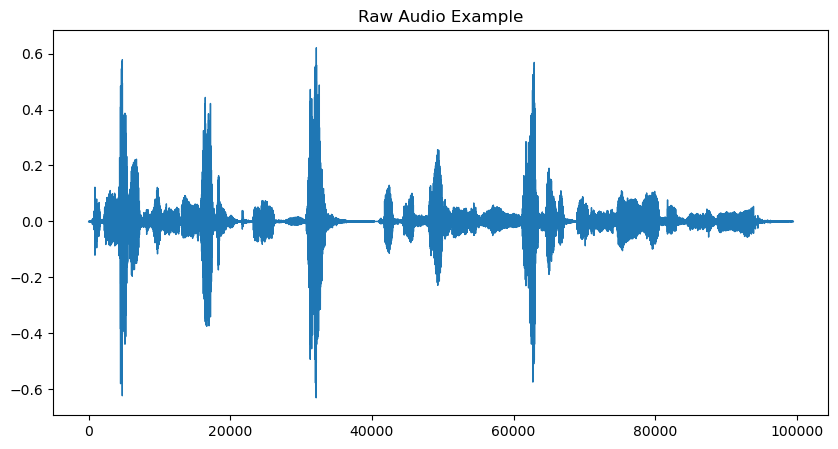

In [14]:
def pre_emphasis(sig, alpha=0.97):
    """
    function:预加重
    para: sig:要进行处理的音频数据
    return 进行加强处理后的音频数据
    """
    # TODO：实现预加重函数（已完成）
    emphasized_sig = np.append(sig[0], sig[1:] - alpha * sig[:-1])
    return emphasized_sig

step1 = pre_emphasis(data) 
pd.Series(step1).plot(figsize=(10, 5),
                  lw=1,
                  title='Raw Audio Example')
plt.show()

#观察对比预加重处理前后的音频图像，图像的哪些特征反应了预加重处理的效果？

##### 3.实现分帧函数

通常帧长25ms,帧位移10ms,为了确保所有帧采样数相等,需要对信号最后进行填充

查看分帧后的shape,分帧后shape变成二维

In [15]:
def framing(sig,fs,frame_len_s=0.025,frame_shift_s=0.01):
    """
    function：分帧
    para：
        frame_len_s:每一帧的长度,单位为s
        frame_shift_s:分帧的shift,单位为s
        fs：采样率，hz
        sig：要进行分帧的音频信号
    return：进行分帧后的数据，一个二维list，一个元素是一帧信号
    """
    # TODO：实现分帧函数（已完成）
    frame_len = int(round(frame_len_s * fs))
    frame_shift = int(round(frame_shift_s * fs))

    if len(sig) <= frame_len:
        num_frames = 1
    else:
        num_frames = int(np.ceil((len(sig) - frame_len) / frame_shift)) + 1

    pad_len = (num_frames - 1) * frame_shift + frame_len
    pad_sig = np.append(sig, np.zeros(pad_len - len(sig)))

    indices = np.tile(np.arange(frame_len), (num_frames, 1)) + np.tile(
        np.arange(0, num_frames * frame_shift, frame_shift), (frame_len, 1)
    ).T
    frame_sig = pad_sig[indices.astype(np.int32, copy=False)]
    return frame_sig

step2 = framing(step1,sr) 
print(step2.shape)

(451, 551)


##### 4.实现加窗函数

hamming窗提示:numpy.hamming()

加窗方式:frame_sig_window(n)=frame_sig(n)⋅window(n)

In [16]:
#Xw(n)=X(n)⋅w(n)
def add_window(frame_sig,fs,frame_len_s=0.025):
    """
    function：加窗
    para：
        frame_len_s：每一帧的长度,单位为s
        fs：采样率
        frame_sig:进行分帧后的数据
    return：加窗后的数据
    """
    # TODO：实现加窗函数（使用hamming窗）（已完成）
    frame_len = frame_sig.shape[1]
    window = np.hamming(frame_len)
    frame_sig_window = frame_sig * window
    return frame_sig_window

step3 = add_window(step2,sr)
step3.shape

# 实际上加窗不止有汉明窗，还有其他窗函数，问问大模型，还有哪些窗函数？让他帮你实现其中一个，最后看看不同窗函数的幅度谱图有什么区别。

(451, 551)

##### 5.实现短时傅里叶变换函数得到幅度谱

nfft通常为256或512

STFT提示:numpy.fft.rfft()

幅度谱需要取模

In [17]:
def stft(frame_sig, nfft=512):    
    """
    function：短时傅里叶变换将帧信号变为帧功率（对应幅值频发）
    para：
        frame_sig: 分帧后的信号
        nfft: fft点数
    return: 返回分帧信号的幅度谱和功率谱
    """
    # TODO：得到幅度谱（已完成）
    fft_res = np.fft.rfft(frame_sig, n=nfft)
    frame_mag = np.abs(fft_res)
    
    # 功率谱
    frame_pow = (frame_mag ** 2) * 1.0 / nfft # 取平方 
    return frame_mag,frame_pow

frame_mag, step4 = stft(step3) 
frame_mag.shape

(451, 257)

##### 6.取对数得到可绘制查看的幅度谱,并绘制

$F_{\text{dB}} = 20 \times \log_{10} (F)$

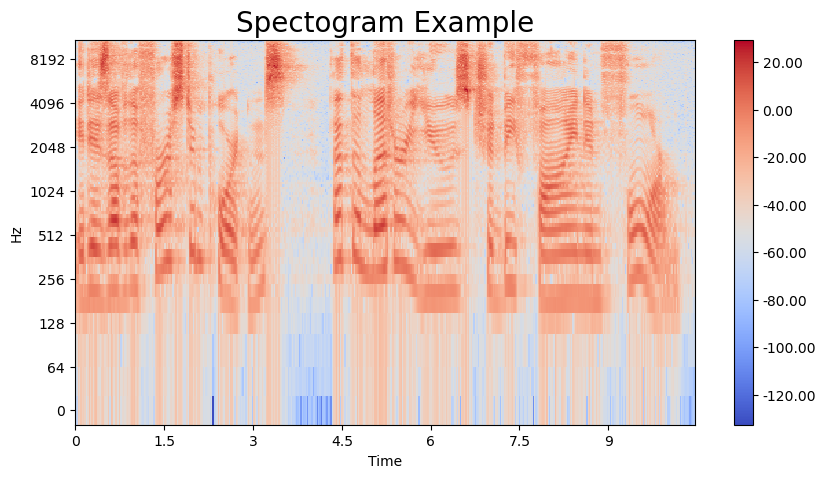

In [18]:
frame_log = 20 * np.log10(frame_mag)
fig, ax = plt.subplots(figsize=(10, 5))
img = librosa.display.specshow(frame_log.T,
                              x_axis='time',
                              y_axis='log',
                              ax=ax)
ax.set_title('Spectogram Example', fontsize=20)
fig.colorbar(img, ax=ax, format=f'%0.2f')
plt.show()

### 课程三 （45%）

实现FBank和MFCC

##### 1.实现mel滤波
人耳对低频更敏感,但对高频变化的分辨率较低,所以要使用Mel频率刻度来更符合人耳的听觉特性.

奈奎斯特采样定理:当采样频率fs.max大于信号中最高频率fmax的2倍时(fs.max>2fmax)，采样之后的数字信号完整地保留了原始信号中的信息。

$n_{\text{filter}}$取40, nfft取512

$M_{\text{min}} = 0$

$M_{\text{max}} = 2595 \log_{10} \left( 1 + \frac{fs}{2 \times 700} \right)$

$M_i = \text{linspace}(M_{\text{min}}, M_{\text{max}}, n_{\text{filter}} + 2)$

$f_i = 700 \left(10^{M_i / 2595} - 1 \right)$

$H_m(k) =
\begin{cases}
  0, & k < f(m-1) \text{ or } k > f(m+1) \\
  \frac{k - f(m-1)}{f(m) - f(m-1)}, & f(m-1) \leq k \leq f(m) \\
  \frac{f(m+1) - k}{f(m+1) - f(m)}, & f(m) < k \leq f(m+1)
\end{cases}$

$\text{filter\_banks} = P \cdot H_m^T$

查看最后维度

In [19]:
def mel_filter(frame_pow, fs, n_filter=40, nfft=512):    
    """
    function:mel 滤波器系数计算
    para:
        frame_pow: 分帧信号功率谱
        fs: 采样率 hz
        n_filter: 滤波器个数
        nfft: fft点数
    return: 分帧信号功率谱mel滤波后的值
    """

    mel_min = 0 # 最低mel值
    mel_max = 2595 * np.log10(1 + (fs / 2) / 700) # 最高mel值，最大信号频率为 fs/2
    mel_points = np.linspace(mel_min, mel_max, n_filter + 2)  # TODO: n_filter个mel值均匀分布与最低与最高mel值之间（已完成）
    hz_points = 700 * (10 ** (mel_points / 2595) - 1)  # TODO: mel值对应回频率点，频率间隔指数化（已完成）
    filter_edge = np.floor(hz_points * (nfft + 1) / fs).astype(int) # 对应到fft的点数比例上

    fbank = np.zeros((n_filter, int(nfft / 2 + 1)))
    # TODO:求mel滤波器系数（已完成）
    for m in range(1, n_filter + 1):
        left = filter_edge[m - 1]
        center = filter_edge[m]
        right = filter_edge[m + 1]

        if center == left:
            center += 1
        if right == center:
            right += 1

        for k in range(left, center):
            fbank[m - 1, k] = (k - left) / (center - left)
        for k in range(center, right):
            fbank[m - 1, k] = (right - k) / (right - center)
    
    # TODO:mel 滤波（已完成）
    # 提示：[num_frame, nfft/2 + 1] * [nfft/2 + 1, n_filter] = [num_frame, n_filter]
    filter_banks = np.dot(frame_pow, fbank.T)

    filter_banks = np.where(filter_banks == 0, np.finfo(float).eps, filter_banks)
    # np.finfo函数是根据括号中的类型来获得信息，获得符合这个类型的数型, eps是取非负的最小值
    return filter_banks
step5 = mel_filter(step4, sr) 
print(step5.shape)

(451, 40)


##### 3.取对数得到可绘制查看的梅尔谱,并绘制,注意矩阵维度,可能需要转置

$P_{\text{dB}} = 20 \times \log_{10} (P)$

In [20]:
fbank = 20 * np.log10(step5)
fbankT = fbank.T   # 方便可视化
print(fbankT.shape)

(40, 451)


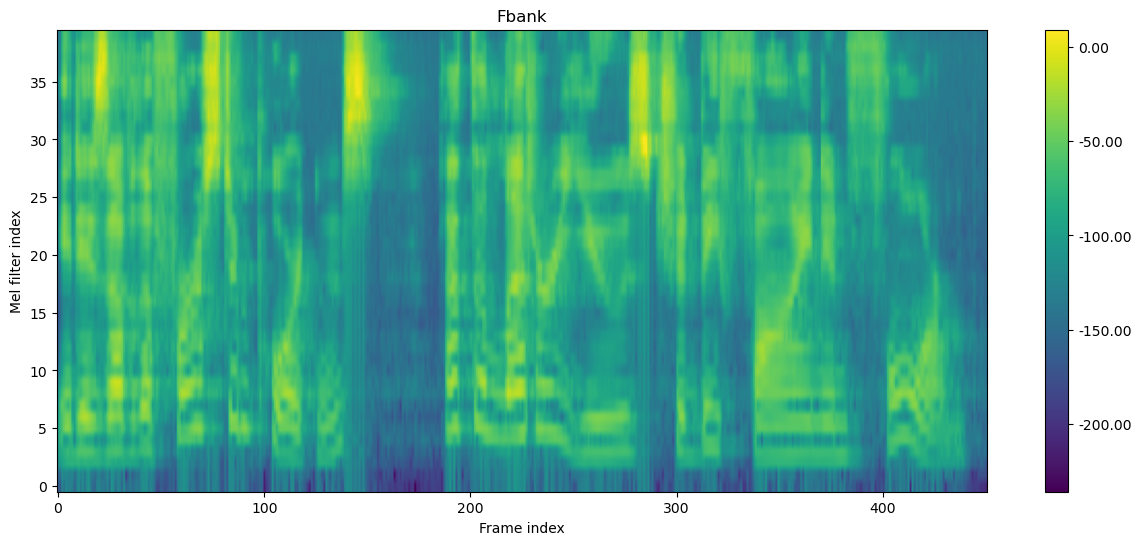

In [21]:
plt.figure(figsize=(15, 6))
plt.imshow(fbankT, origin='lower', aspect='auto')
plt.colorbar(format='%0.2f')
plt.title("Fbank")
plt.xlabel("Frame index")
plt.ylabel("Mel filter index")
plt.show()

##### 4.使用fbank经过离散余弦变换函数得到mfcc,并绘图

In [22]:
from scipy.fftpack import dct
def discrete_cosine_transform(filter_banks):
    """
    function：离散余弦变换
    para：filter_banks:fbanks
    return: mfcc
    """
    num_ceps = 12
    # TODO: 离散余弦变换（已完成）
    mfcc = dct(filter_banks, type=2, axis=1, norm='ortho')[:, 1:num_ceps + 1]
    """
    scipy.fftpack.dct:返回任意类型序列x的离散余弦变换。
    """
    return mfcc
mfcc  = discrete_cosine_transform(fbank)
mfcc.shape

(451, 12)

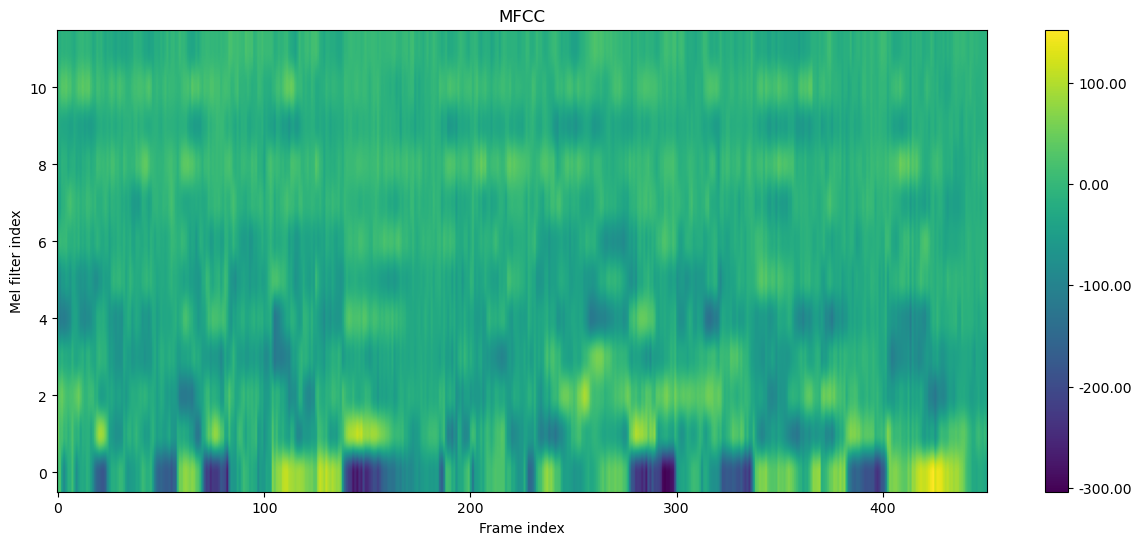

In [23]:
plt.figure(figsize=(15, 6))
plt.imshow(mfcc.T, origin='lower', aspect='auto')
plt.colorbar(format='%0.2f')
plt.title("MFCC")
plt.xlabel("Frame index")
plt.ylabel("Mel filter index")
plt.show()

### 课程四（加分项：10%）
           

基于预训练模型的深度音频特征提取

在前面的实验中，你已经学会了如何手动提取传统的音频特征（MFCC、FBank）。近年来，基于深度学习的预训练模型（如 **Wav2Vec2、HuBERT、Whisper**）可以从音频中自动学习到更强大的特征表示，广泛应用于语音识别、说话人识别等任务。本实验需要你加载一个预训练的 **Wav2Vec2** 或**HuBERT**模型（二选一），用它来提取示例音频LJ001-0011.wav的深度特征。

Wav2Vec2模型：

torchaudio文档：https://docs.pytorch.org/audio/stable/generated/torchaudio.models.Wav2Vec2Model.html

Hugging Face Transformers文档：https://huggingface.co/docs/transformers/model_doc/wav2vec2

HuBERT模型：

github仓库：https://github.com/facebookresearch/fairseq/tree/main/examples/hubert

Hugging Face Transformers文档：https://huggingface.co/docs/transformers/model_doc/hubert

注：HuBERT和Wav2Vec2模型对于输入音频的采样率均有要求，你可能需要对音频进行重采样以符合模型的要求。

Deep feature shape: torch.Size([225, 768])


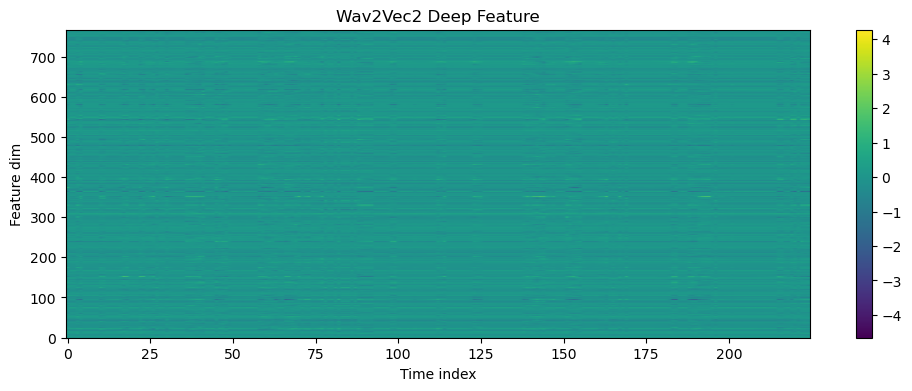

In [43]:
#TODO：深度音频特征提取（已完成）
import torch
import torchaudio
import matplotlib.pyplot as plt

wav_path = "LJ001-0011.wav"
bundle = torchaudio.pipelines.WAV2VEC2_BASE
target_sr = bundle.sample_rate

waveform, sample_rate = torchaudio.load(wav_path)
if waveform.size(0) > 1:
    waveform = waveform.mean(dim=0, keepdim=True)

if sample_rate != target_sr:
    waveform = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=target_sr)(waveform)

try:
    model = bundle.get_model().eval()
    with torch.inference_mode():
        features, _ = model.extract_features(waveform)
    deep_feature = features[-1].squeeze(0)
    print("Deep feature shape:", deep_feature.shape)

    plt.figure(figsize=(12, 4))
    plt.imshow(deep_feature.T.cpu().numpy(), aspect="auto", origin="lower")
    plt.colorbar()
    plt.title("Wav2Vec2 Deep Feature")
    plt.xlabel("Time index")
    plt.ylabel("Feature dim")
    plt.show()
except Exception as e:
    deep_feature = None
    print("Wav2Vec2 预训练权重加载失败，请检查网络后重试。")
    print("错误信息:", e)